# Visualisasi Pengujian Berdasarkan Perangkat dan Jarak Efektif

Notebook ini menampilkan analisis pengaruh **jarak pengambilan gambar** terhadap akurasi dan performa inferensi CNN FreshScan.

| Aspek | Perangkat | Keterangan |
|---|---|---|
| **Fokus Jarak** | Redmi 9A | Ada data ROI Crop → visualisasi sample |
| **Pembanding Jarak** | Redmi Note 10 Pro | Perbandingan akurasi & inference time |

Jarak yang diuji: **10 cm**, **20 cm**, **30 cm** (+ tanpa jarak sebagai baseline)  
Kelas yang diuji pada pengujian jarak: **Jeruk Segar**, **Mangga Busuk**, **Pisang Segar**  
Total gambar ROI Crop Redmi 9A: 1800 gambar  

Semua grafik tersimpan ke `outputs/pengujian_perangkat_jarak/` dengan resolusi 300 DPI.

## 1. Import Library dan Konfigurasi

In [9]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from IPython.display import display

# ── Path Konfigurasi ─────────────────────────────────────────────────────────
ROOT        = Path.cwd()
DATASET_DIR = ROOT / "dataset"
OUTPUT_DIR  = ROOT / "outputs" / "pengujian_perangkat_jarak"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEV_9A   = "Redmi 9A"
DEV_NOTE = "Redmi Note 10 Pro"

JARAK_MAP   = {"tanpa jarak": "Tanpa Jarak", "10 cm": "10 cm",
               "20 cm": "20 cm", "30 cm": "30 cm"}
JARAK_ORDER = ["Tanpa Jarak", "10 cm", "20 cm", "30 cm"]

PALETTE = {
    "tanpa" : "#009E73",
    "10cm"  : "#56B4E9",
    "20cm"  : "#E69F00",
    "30cm"  : "#D55E00",
    "note10": "#2196F3",
    "9a"    : "#FF9800",
}
JARAK_COLOR = {
    "Tanpa Jarak": PALETTE["tanpa"],
    "10 cm"      : PALETTE["10cm"],
    "20 cm"      : PALETTE["20cm"],
    "30 cm"      : PALETTE["30cm"],
}

# ══════════════════════════════════════════════════════════════════════════════
# HALAMAN KONFIGURASI FONT — UBAH DI SINI UNTUK MENGATUR SEMUA UKURAN
# ══════════════════════════════════════════════════════════════════════════════
FONT_CFG = {
    # ── Judul Grafik ──────────────────────────────────────────────────────
    "title"              : 22,   # Judul utama grafik (sebelumnya 24)
    "suptitle"           : 24,   # Super title (suptitle) untuk multi-panel
    
    # ── Label Sumbu ───────────────────────────────────────────────────────
    "axis_label"         : 20,   # Label sumbu X dan Y (sebelumnya 30)
    
    # ── Tick Labels (Nama Buah/Sayuran) ───────────────────────────────────
    "tick_label"         : 18,   # Label tick sumbu-x/y, NAMA BUAH/SAYURAN (sebelumnya 30)
    
    # ── Anotasi & Data Label ──────────────────────────────────────────────
    "bar_annotation"     : 14,   # Angka di atas bar chart (sebelumnya 17)
    "data_label"         : 16,   # Label data pada grafik (sebelumnya 20)
    "stacked_inside"     : 16,   # Angka di dalam stacked bar (sebelumnya 20)
    "stacked_outside"    : 14,   # Angka "Salah: X" di luar bar
    
    # ── Legend ────────────────────────────────────────────────────────────
    "legend"             : 16,   # Ukuran font legend (sebelumnya 20)
    "legend_title"       : 16,   # Judul legend
    
    # ── Confusion Matrix ──────────────────────────────────────────────────
    "cm_tick"            : 14,   
    "cm_cell"            : 15,   
    "colorbar_label"     : 20,   
    
    # ── Sub-panel (multi-axes) ────────────────────────────────────────────
    "subplot_title"      : 20,   
    "subplot_axis_label" : 20,   
    "subplot_legend"     : 20,   
    
    # ── Confidence Distribution ───────────────────────────────────────────
    "hist_title"         : 20,   
    "hist_axis"          : 20,   
    "hist_legend"        : 20,   
    
    # ── Global rcParams ───────────────────────────────────────────────────
    "global_font"        : 16,   # Ukuran font dasar global (sebelumnya 20)
    "global_title"       : 22,   # axes.titlesize (sebelumnya 24)
    "global_axis"        : 20,   # axes.labelsize (sebelumnya 20)
    "global_tick"        : 18,   # xtick/ytick.labelsize (sebelumnya 20)
    "global_legend"      : 16,   # legend.fontsize (sebelumnya 20)
}

plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300,
    "font.size": FONT_CFG["global_font"], 
    "axes.titlesize": FONT_CFG["global_title"], 
    "axes.labelsize": FONT_CFG["global_axis"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    "legend.frameon": False,
})

print(f"Root   : {ROOT}")
print(f"Output : {OUTPUT_DIR}")


Root   : c:\Users\Muhamad Muslih\Desktop\CnnFreshScanResearch
Output : c:\Users\Muhamad Muslih\Desktop\CnnFreshScanResearch\outputs\pengujian_perangkat_jarak


## 2. Fungsi Helper & Load Data Jarak

In [10]:
ITEM_MAP = {"orange": "Jeruk", "mango": "Mangga", "banana": "Pisang",
            "cucumber": "Mentimun", "tomato": "Tomat", "carrot": "Wortel"}

def kondisi_from_label(label):
    if "_fresh_" in label:  return "Segar"
    if "_rotten_" in label: return "Busuk"
    return "Tidak Diketahui"

def komoditas_from_label(label):
    return ITEM_MAP.get(label.split("_")[-1], label.split("_")[-1].title())

def kelas_from_label(label):
    return f"{komoditas_from_label(label)} {kondisi_from_label(label)}"


def load_distance_data(device_name: str):
    """Baca semua data per jarak untuk sebuah perangkat.
    Jika satu kelas-jarak memiliki beberapa sesi, hanya sesi pertama
    (timestamp terkecil dari nama file) yang digunakan.
    """
    records    = []
    raw_frames = []
    seen_keys  = set()   # (jarak_label, kelas_aktual) sudah diproses

    for folder_name, jarak_label in JARAK_MAP.items():
        folder = DATASET_DIR / device_name / folder_name
        if not folder.exists():
            print(f"  Folder tidak ditemukan: {folder}")
            continue

        # Per sub-folder kelas, ambil hanya 1 sesi (JSON pertama)
        for kelas_folder in sorted(folder.iterdir()):
            if not kelas_folder.is_dir():
                continue

            summary_paths = sorted(kelas_folder.glob("camera_roi_inference_summary_*.json"))
            if not summary_paths:
                continue

            # Ambil sesi pertama saja
            summary_path = summary_paths[0]
            with summary_path.open("r", encoding="utf-8") as f:
                summary = json.load(f)

            kelas_aktual = kelas_from_label(summary["actualLabel"])
            key = (jarak_label, kelas_aktual)
            if key in seen_keys:
                print(f"  [Skip duplikat] {device_name} / {jarak_label} / {kelas_aktual}")
                continue
            seen_keys.add(key)

            csv_candidates = sorted(summary_path.parent.glob("camera_roi_inference_report_*.csv"))
            if not csv_candidates:
                continue

            df = pd.read_csv(csv_candidates[0])

            for col in ["captureIndex", "confidence", "roiCropTimeMs",
                        "preprocessingTimeMs", "inferenceTimeMs", "totalTimeMs"]:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")

            df["isCorrect"]       = df["isCorrect"].astype(str).str.lower().eq("true")
            df["Perangkat"]       = device_name
            df["Jarak"]           = jarak_label
            df["Kelas Aktual"]    = kelas_aktual
            df["Kondisi"]         = kondisi_from_label(summary["actualLabel"])
            df["Prediksi Kelas"]  = df["predictedLabel"].astype(str).map(kelas_from_label)
            raw_frames.append(df)

            records.append({
                "Perangkat"                  : device_name,
                "Jarak"                      : jarak_label,
                "Kelas Aktual"               : kelas_aktual,
                "Kondisi"                    : kondisi_from_label(summary["actualLabel"]),
                "Jumlah Capture"             : int(summary["totalCaptures"]),
                "Benar"                      : int(summary["correctPrediction"]),
                "Salah"                      : int(summary["wrongPrediction"]),
                "Akurasi (%)"                : float(summary["accuracy"]) * 100,
                "Rata-rata Inference (ms)"   : float(summary["meanInferenceMs"]),
                "Median Inference (ms)"      : float(summary["medianInferenceMs"]),
                "P95 Inference (ms)"         : float(summary["p95InferenceMs"]),
                "Min Inference (ms)"         : float(summary["minInferenceMs"]),
                "Max Inference (ms)"         : float(summary["maxInferenceMs"]),
                "Rata-rata Preprocessing (ms)": float(summary.get("meanPreprocessingMs", 0)),
                "Rata-rata ROI Crop (ms)"    : float(summary.get("meanRoiCropMs", 0)),
            })

    raw_df   = pd.concat(raw_frames, ignore_index=True) if raw_frames else pd.DataFrame()
    ring_df  = pd.DataFrame(records)
    return ring_df, raw_df


print("Memuat data Redmi 9A ...")
ring_9a, raw_9a = load_distance_data(DEV_9A)
print(f"  → {len(ring_9a)} entri, {len(raw_9a)} baris")

print("Memuat data Redmi Note 10 Pro ...")
ring_note, raw_note = load_distance_data(DEV_NOTE)
print(f"  → {len(ring_note)} entri, {len(raw_note)} baris")

ring_all = pd.concat([ring_9a, ring_note], ignore_index=True)
raw_all  = pd.concat([raw_9a,  raw_note],  ignore_index=True)

# Kelas pada pengujian jarak (bukan tanpa jarak)
KELAS_JARAK = sorted(
    ring_9a.loc[ring_9a["Jarak"] != "Tanpa Jarak", "Kelas Aktual"].unique().tolist()
)
print(f"\nKelas pengujian jarak: {KELAS_JARAK}")

Memuat data Redmi 9A ...
  → 21 entri, 1470 baris
Memuat data Redmi Note 10 Pro ...
  → 21 entri, 1470 baris

Kelas pengujian jarak: ['Jeruk Segar', 'Mangga Busuk', 'Pisang Segar']


## 3. Fungsi Bantu Visualisasi

In [11]:
def simpan_gambar(fig, nama_file):
    fig.tight_layout()
    path = OUTPUT_DIR / nama_file
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  Disimpan: {path.name}")
    return path

def label_wrap(labels, sep=" "):
    return [str(l).replace(sep, "\n") for l in labels]

print("Fungsi bantu siap.")

Fungsi bantu siap.


## 4. Sampel Gambar ROI Crop Berdasarkan Jarak (Gambar 4.32)


Jumlah sampel gambar yang divisualisasikan: 9


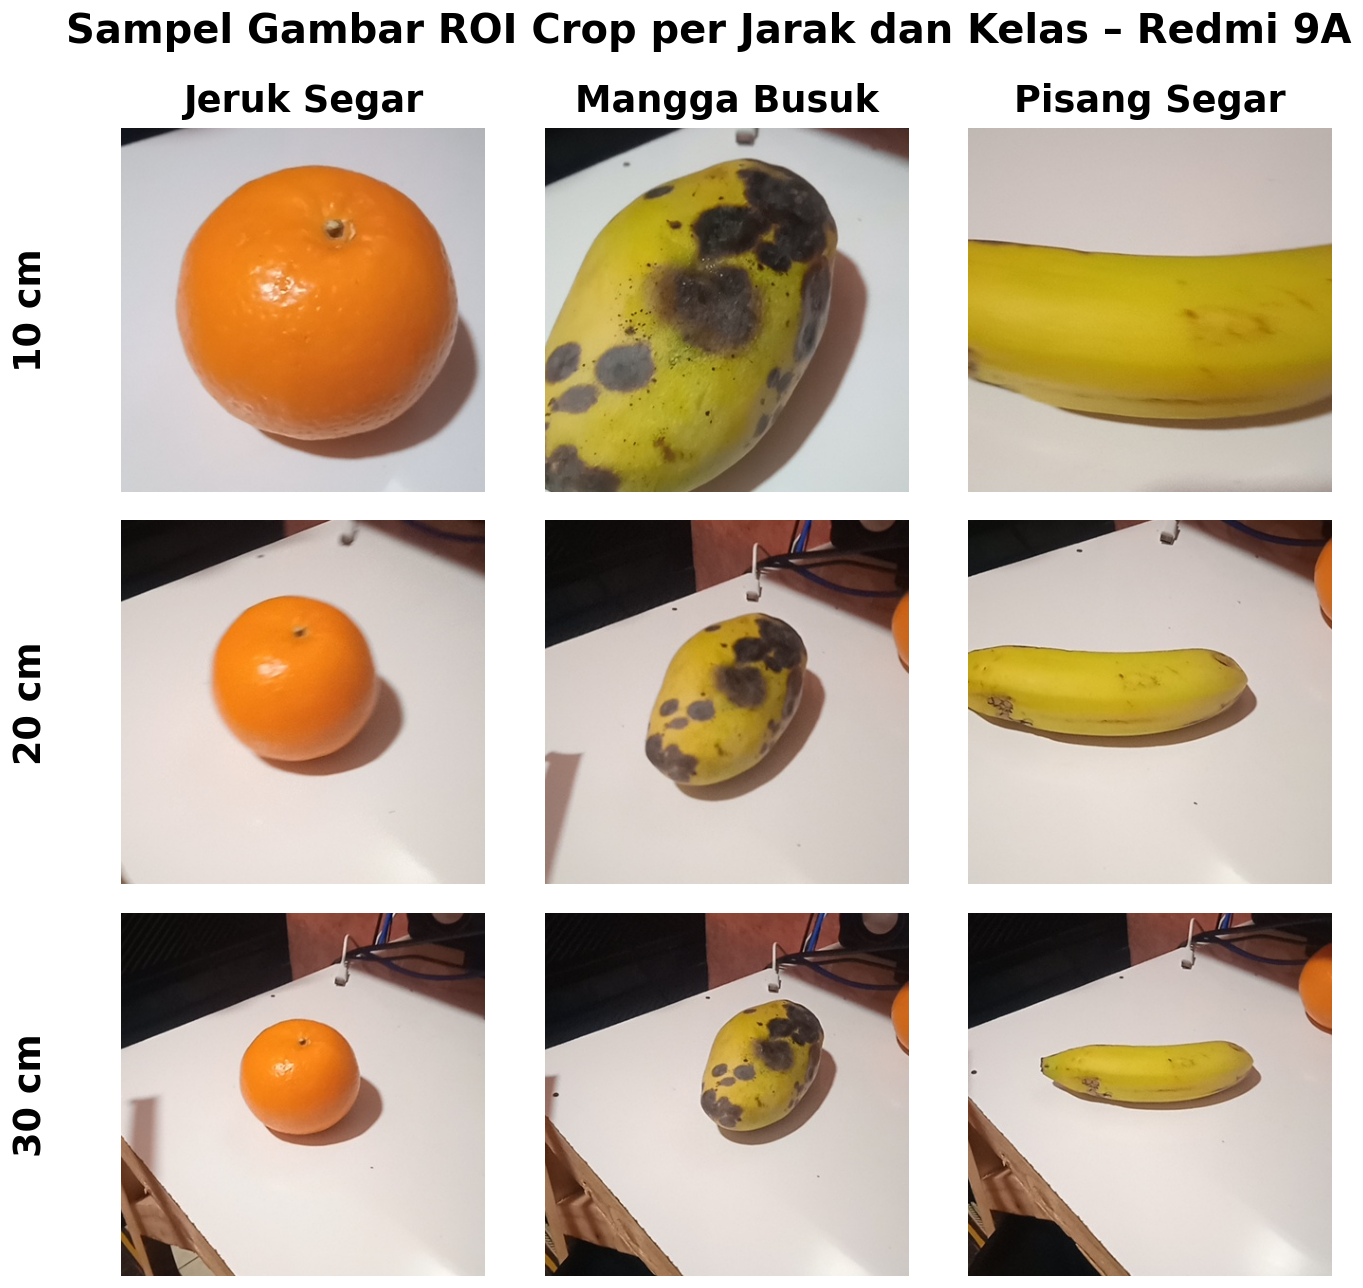

  Disimpan: 00_sampel_roi_crop_redmi9a.png


In [12]:
roi_folder = DATASET_DIR / DEV_9A / "data crop roi"

if not roi_folder.exists():
    print(f"Folder ROI tidak ditemukan: {roi_folder}")
else:
    # Filter data raw_9a untuk jarak 10, 20, 30 cm dan kelas yang sesuai
    jarak_target = ["10 cm", "20 cm", "30 cm"]
    kelas_target = ["Jeruk Segar", "Mangga Busuk", "Pisang Segar"]
    
    sub_raw_9a = raw_9a[
        (raw_9a["Jarak"].isin(jarak_target)) & 
        (raw_9a["Kelas Aktual"].isin(kelas_target))
    ].copy()
    
    # Ambil contoh representatif untuk setiap kombinasi Jarak dan Kelas Aktual
    # Kita akan ambil sampel di tengah (misal index ke-15) untuk visualisasi yang baik
    sampel_rows = []
    for j in jarak_target:
        for k in kelas_target:
            group = sub_raw_9a[(sub_raw_9a["Jarak"] == j) & (sub_raw_9a["Kelas Aktual"] == k)]
            if not group.empty:
                # Ambil baris ke-15 (tengah) agar representatif
                idx = min(15, len(group) - 1)
                sampel_rows.append(group.iloc[idx])
                
    print(f"Jumlah sampel gambar yang divisualisasikan: {len(sampel_rows)}")
    
    # Plot grid 3x3 (3 Jarak x 3 Kelas)
    fig, axes = plt.subplots(3, 3, figsize=(12, 11))
    fig.suptitle(
        "Sampel Gambar ROI Crop per Jarak dan Kelas – Redmi 9A",
        fontsize=FONT_CFG["suptitle"], fontweight="bold", y=0.98
    )
    
    # Judul kolom (Kelas)
    for col_idx, k in enumerate(kelas_target):
        axes[0, col_idx].set_title(k, fontsize=FONT_CFG["title"], fontweight="bold", pad=10)
        
    for i, row in enumerate(sampel_rows):
        row_idx = i // 3
        col_idx = i % 3
        ax = axes[row_idx, col_idx]
        
        # Cari nama file gambar dari path asli di CSV
        img_name = Path(row["savedRoiImagePath"]).name
        img_path = roi_folder / img_name
        
        try:
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {e}", ha="center", va="center", transform=ax.transAxes, fontsize=FONT_CFG["legend"])
            
        ax.axis("off")
        
        # Tampilkan informasi prediksi dan kebenaran
        is_correct = row["isCorrect"]
        color = "green" if is_correct else "red"
        status_text = "Benar" if is_correct else "Salah"
        
        # Label Jarak di sisi kiri untuk kolom pertama
        if col_idx == 0:
            ax.text(-0.25, 0.5, row["Jarak"], transform=ax.transAxes, 
                    fontsize=FONT_CFG["title"], fontweight="bold", rotation=90, 
                    ha="center", va="center")
            
        # Detail informasi inferensi dihilangkan sesuai permintaan (hanya menampilkan gambar saja)
        pass
        
    plt.tight_layout()
    fig.subplots_adjust(top=0.90, bottom=0.12, hspace=0.35, wspace=0.2)
    simpan_gambar(fig, "00_sampel_roi_crop_redmi9a.png")




## 5. Konversi Kategori Jarak (Dependensi)


In [13]:
for perangkat, ring_df in [(DEV_9A, ring_9a), (DEV_NOTE, ring_note)]:
    ring_df['Jarak'] = pd.Categorical(ring_df['Jarak'], categories=JARAK_ORDER, ordered=True)
    ring_df.sort_values(['Jarak', 'Kelas Aktual'], inplace=True, ignore_index=True)


## 6. Grafik Akurasi Rata-rata Berdasarkan Jarak Pengambilan Gambar (Gambar 4.33)


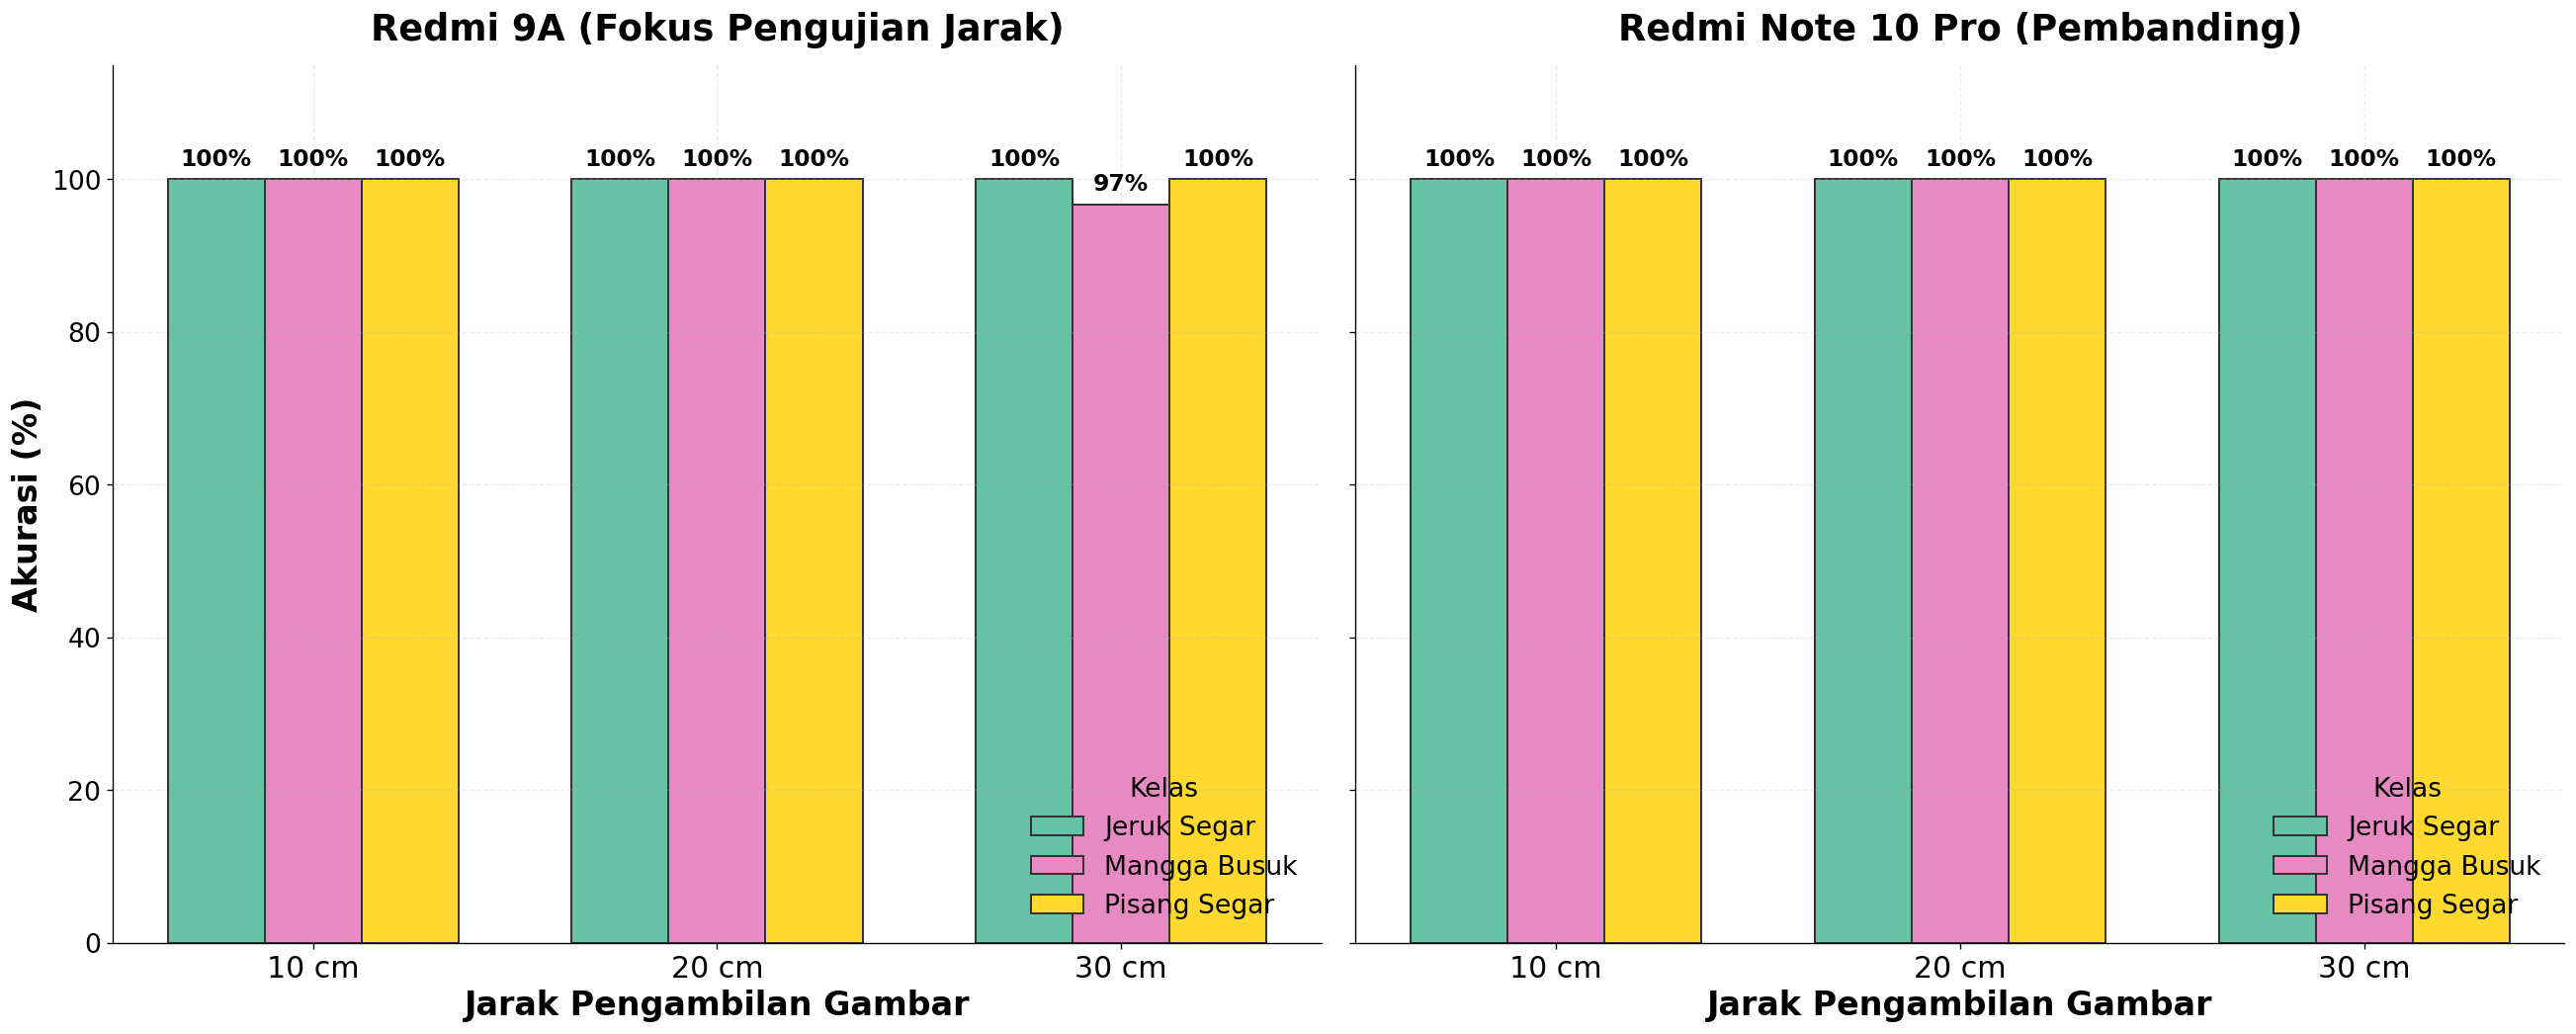

  Disimpan: 03_perbandingan_akurasi_jarak.png


WindowsPath('c:/Users/Muhamad Muslih/Desktop/CnnFreshScanResearch/outputs/pengujian_perangkat_jarak/03_perbandingan_akurasi_jarak.png')

In [14]:
# 6. Grafik Perbandingan Akurasi per Jarak dan Kelas (Gambar 4.33)
jarak_list_3 = ["10 cm", "20 cm", "30 cm"]
kelas_ujian  = ["Jeruk Segar", "Mangga Busuk", "Pisang Segar"]
COLORS_JARAK = {
    "Jeruk Segar": "#66c2a5",
    "Mangga Busuk": "#e78ac3",
    "Pisang Segar": "#ffd92f"
}

x_j   = np.arange(len(jarak_list_3))
width = 0.24

fig, axes = plt.subplots(1, 2, figsize=(22, 9), sharey=True)

# Loop untuk kedua perangkat
for idx, (perangkat, ring_df, title_suffix) in enumerate([
    ("Redmi 9A", ring_9a, "Redmi 9A (Fokus Pengujian Jarak)"),
    ("Redmi Note 10 Pro", ring_note, "Redmi Note 10 Pro (Pembanding)")
]):
    ax = axes[idx]
    
    # Filter data untuk jarak target & kelas target
    sub_df = ring_df[ring_df["Jarak"].isin(jarak_list_3) & ring_df["Kelas Aktual"].isin(kelas_ujian)].copy()
    
    # Plot bars untuk masing-masing kelas
    for k_idx, kelas in enumerate(kelas_ujian):
        kelas_data = sub_df[sub_df["Kelas Aktual"] == kelas].copy()
        # Urutkan berdasarkan jarak_list_3
        kelas_data["Jarak"] = pd.Categorical(kelas_data["Jarak"], categories=jarak_list_3, ordered=True)
        kelas_data = kelas_data.sort_values("Jarak")
        
        y_vals = kelas_data["Akurasi (%)"].tolist()
        # Jika y_vals kurang dari 3 (karena data kosong), tambahkan padding 0
        while len(y_vals) < len(jarak_list_3):
            y_vals.append(0)
            
        pos = x_j + (k_idx - 1) * width
        bars = ax.bar(pos, y_vals, width, label=kelas, color=COLORS_JARAK[kelas], edgecolor="#333", linewidth=1.2)
        
        # Tambahkan teks akurasi di atas bar
        for bar, val in zip(bars, y_vals):
            ax.text(bar.get_x() + bar.get_width()/2, val + 1.2,
                    f"{val:.0f}%", ha="center", va="bottom", fontsize=FONT_CFG["bar_annotation"], fontweight="bold")

    ax.set_title(title_suffix, fontsize=FONT_CFG["title"], fontweight="bold", pad=15)
    ax.set_xlabel("Jarak Pengambilan Gambar", fontsize=FONT_CFG["axis_label"], fontweight="bold")
    ax.set_xticks(x_j)
    ax.set_xticklabels(jarak_list_3, fontsize=FONT_CFG["tick_label"])
    
    if idx == 0:
        ax.set_ylabel("Akurasi (%)", fontsize=FONT_CFG["axis_label"], fontweight="bold")
        
    ax.legend(title="Kelas", loc="lower right", fontsize=FONT_CFG["legend"], title_fontsize=FONT_CFG["legend_title"])
    ax.set_ylim(0, 115)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
simpan_gambar(fig, "03_perbandingan_akurasi_jarak.png")



## 7. Perhitungan Rata-rata Inference per Jarak (Dependensi)


In [15]:
jarak_list_3 = ['10 cm', '20 cm', '30 cm']
def avg_inf_per_jarak(ring_df, jarak_list):
    return (
        ring_df.loc[ring_df['Jarak'].isin(jarak_list)]
        .groupby('Jarak', observed=True)['Rata-rata Inference (ms)']
        .mean().reindex(jarak_list).reset_index()
    )
inf_9a_3   = avg_inf_per_jarak(ring_9a,   jarak_list_3)
inf_note_3 = avg_inf_per_jarak(ring_note, jarak_list_3)



## 8. Grafik Waktu Inferensi Berdasarkan Jarak Pengambilan Gambar (Gambar 4.34)


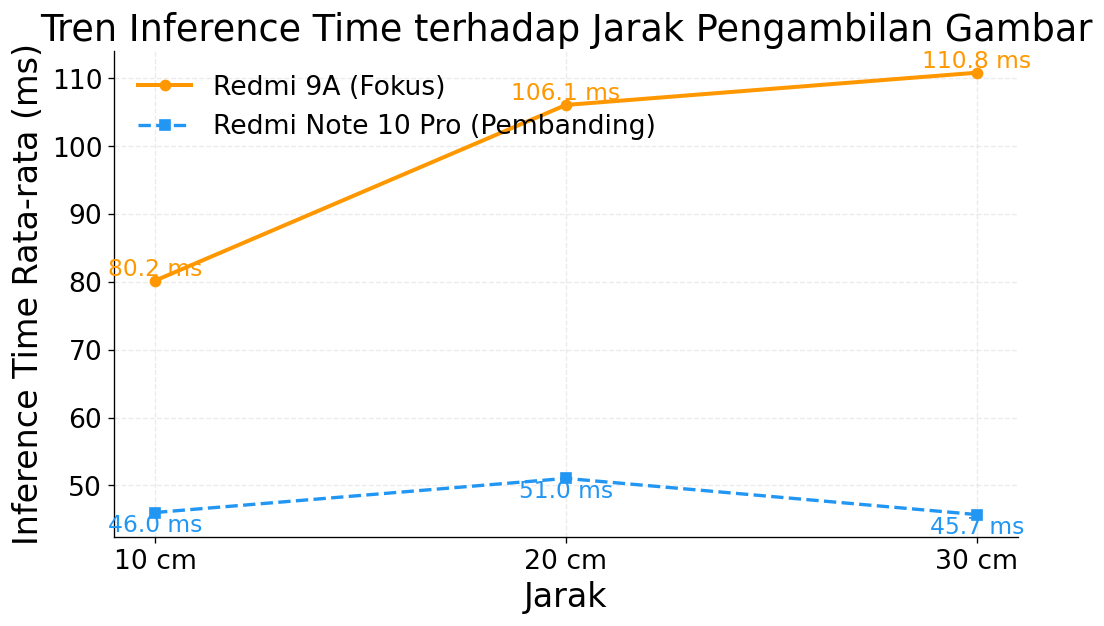

  Disimpan: 05_tren_inference_vs_jarak.png


WindowsPath('c:/Users/Muhamad Muslih/Desktop/CnnFreshScanResearch/outputs/pengujian_perangkat_jarak/05_tren_inference_vs_jarak.png')

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(inf_9a_3["Jarak"],   inf_9a_3["Rata-rata Inference (ms)"],
        marker="o", linewidth=2.4, color=PALETTE["9a"],   label="Redmi 9A (Fokus)")
ax.plot(inf_note_3["Jarak"], inf_note_3["Rata-rata Inference (ms)"],
        marker="s", linewidth=2.0, color=PALETTE["note10"], linestyle="--",
        label="Redmi Note 10 Pro (Pembanding)")

for _, row in inf_9a_3.iterrows():
    ax.text(row["Jarak"], row["Rata-rata Inference (ms)"] + 0.8,
            f"{row['Rata-rata Inference (ms)']:.1f} ms",
            ha="center", fontsize=FONT_CFG["bar_annotation"], color=PALETTE["9a"])
for _, row in inf_note_3.iterrows():
    ax.text(row["Jarak"], row["Rata-rata Inference (ms)"] - 2.8,
            f"{row['Rata-rata Inference (ms)']:.1f} ms",
            ha="center", fontsize=FONT_CFG["bar_annotation"], color=PALETTE["note10"])

ax.set_title("Tren Inference Time terhadap Jarak Pengambilan Gambar")
ax.set_xlabel("Jarak")
ax.set_ylabel("Inference Time Rata-rata (ms)")
ax.legend(loc="upper left", fontsize=FONT_CFG["legend"])
simpan_gambar(fig, "05_tren_inference_vs_jarak.png")

